## Replicate reproducibility

In [11]:
%run _config.ipynb

In [12]:
REPRO_LEVELS = ["untrt_intra", "untrt_inter", "trt_intra", "trt_inter", "delta_intra", "delta_inter"]
REPRO_PATH = {
    "tahoe": {level: TAHOE_REPRO / f"repro_{level}.csv" for level in REPRO_LEVELS},
    "lincs": {level: LINCS_REPRO / f"repro_{level}.csv" for level in REPRO_LEVELS},
}

repro = {
    ds: {level: pd.read_csv(REPRO_PATH[ds][level]) for level in REPRO_LEVELS}
    for ds in DATASETS
}

for ds in DATASETS:
    for level in REPRO_LEVELS:
        print(f"{ds} {level}: {len(repro[ds][level]):,} pairs")

tahoe untrt_intra: 666 pairs
tahoe untrt_inter: 17,304 pairs
tahoe trt_intra: 376 pairs
tahoe trt_inter: 12,768 pairs
tahoe delta_intra: 376 pairs
tahoe delta_inter: 12,755 pairs
lincs untrt_intra: 540,425 pairs
lincs untrt_inter: 39,743 pairs
lincs trt_intra: 114,970 pairs
lincs trt_inter: 1,603,752 pairs
lincs delta_intra: 114,970 pairs
lincs delta_inter: 1,603,752 pairs


In [13]:
# One average per condition (cell line, drug, dose, time, (plate))
# Collapses replicate-pair-level rows to one row per condition, so conditions
# with many replicate pairs don't dominate downstream stats/plots.
def condition_avg(df):
    group_cols = ["cell_line", "drug", "dose", "time"]
    if "plate" in df.columns:
        group_cols = group_cols + ["plate"]

    grp = df.groupby(group_cols, dropna=False)
    agg = grp[METRICS].mean().reset_index()
    agg["n_pairs"] = grp.size().values
    return agg

repro_cond = {
    ds: {level: condition_avg(repro[ds][level]) for level in REPRO_LEVELS}
    for ds in DATASETS
}

for ds in DATASETS:
    for level in REPRO_LEVELS:
        print(f"{ds} {level}: {len(repro_cond[ds][level]):,} conditions (from {len(repro[ds][level]):,} pairs)")

tahoe untrt_intra: 666 conditions (from 666 pairs)
tahoe untrt_inter: 48 conditions (from 17,304 pairs)
tahoe trt_intra: 376 conditions (from 376 pairs)
tahoe trt_inter: 6,939 conditions (from 12,768 pairs)
tahoe delta_intra: 376 conditions (from 376 pairs)
tahoe delta_inter: 6,938 conditions (from 12,755 pairs)
lincs untrt_intra: 4,993 conditions (from 540,425 pairs)
lincs untrt_inter: 240 conditions (from 39,743 pairs)
lincs trt_intra: 19,286 conditions (from 114,970 pairs)
lincs trt_inter: 336,809 conditions (from 1,603,752 pairs)
lincs delta_intra: 19,286 conditions (from 114,970 pairs)
lincs delta_inter: 336,809 conditions (from 1,603,752 pairs)


In [14]:
# ── Repro – Ridge Plot (condition-averaged, intra- & inter-plate overlaid) ──
def _tint(hex_color, amount=0.55):
    r, g, b = mcolors.to_rgb(hex_color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

# 6 colors: a light/dark pair per profile type (intra = light, inter = dark)
PLATE_COLOR = {
    ("delta", "intra"): LBLUE,
    ("delta", "inter"): DBLUE,
    ("trt",   "intra"): _tint(RED, 0.55),
    ("trt",   "inter"): RED,
    ("untrt", "intra"): _tint(GREY, 0.55),
    ("untrt", "inter"): GREY,
}

_R_ROWS = [
    ("tahoe", "delta", "Δ"),
    ("tahoe", "trt",   "treated"),
    ("tahoe", "untrt", "untreated"),
    ("lincs", "delta", "Δ"),
    ("lincs", "trt",   "treated"),
    ("lincs", "untrt", "untreated"),
]

# ── Constants ─────────────────────────────────────────────────
X_LIM     = (-0.55, 1.02)
BINS      = np.linspace(*X_LIM, 100)
FIG_W     = 7.0
FIG_H     = 6.0
LEFT_MAR  = 0.08
AXES_W    = 0.58
ROW_H     = 0.16
ROW_GAP   = 0.015
GROUP_GAP = 0.06
LABEL_OFFSET = 0.07

# ── Build bottom positions ────────────────────────────────────
group_sizes = [3, 3]
bottoms = []
cursor = 0.06
for g, size in enumerate(reversed(group_sizes)):
    group_bottoms = []
    for r in range(size):
        group_bottoms.append(cursor)
        cursor += ROW_H + ROW_GAP
    bottoms.extend(reversed(group_bottoms))
    cursor += (GROUP_GAP - ROW_GAP)
bottoms = list(reversed(bottoms))

bottom_min = min(bottoms)
bottom_max = max(bottoms)

# ── Figure & axes ─────────────────────────────────────────────
n   = len(_R_ROWS)
fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.suptitle("Replicate reproducibility (condition-averaged) — intra- vs. inter-plate",
             fontsize=FS_TITLE, y=bottom_max + ROW_H + 0.05)

axes = []
for i in range(n):
    ax = fig.add_axes([LEFT_MAR, bottoms[i], AXES_W, ROW_H])
    axes.append(ax)

def add_median(ax, vals, color, proft, ymax, y_mult):
    med = np.median(vals)
    ax.axvline(med, color=color, lw=1.2, ls="--", alpha=0.85)
    if proft == "trt":
        label_x = med - LABEL_OFFSET
    elif proft == "untrt":
        label_x = med + LABEL_OFFSET
    else:
        label_x = med
    ax.text(label_x, ymax * y_mult, f"{med:.2f}",
            ha="center", va="bottom", fontsize=FS_TINY, color=color)
    return med

# ── Plot histograms ───────────────────────────────────────────
row_n = {}
for ci, (ax, (ds, proft, row_title)) in enumerate(zip(axes, _R_ROWS)):
    vals_intra = repro_cond[ds][f"{proft}_intra"]["pearson"].dropna().values
    vals_inter = repro_cond[ds][f"{proft}_inter"]["pearson"].dropna().values
    row_n[ci] = (len(vals_intra), len(vals_inter))

    c_intra = PLATE_COLOR[(proft, "intra")]
    c_inter = PLATE_COLOR[(proft, "inter")]
    fill_alpha = 0.75 if proft == "delta" else 0.35

    counts_intra, edges = np.histogram(vals_intra, bins=BINS, density=True)
    counts_inter, _     = np.histogram(vals_inter, bins=BINS, density=True)
    ymax = max(counts_intra.max(), counts_inter.max())

    ax.stairs(counts_inter, edges, fill=True, color=c_inter, alpha=fill_alpha, lw=0, zorder=1)
    ax.stairs(counts_intra, edges, fill=True, color=c_intra, alpha=fill_alpha, lw=0, zorder=2)

    ax.set_zorder(2 if proft == "delta" else 1)
    ax.patch.set_alpha(0)

    ax.text(1.01, 0.0, row_title,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=10, color=c_inter, alpha=0.95)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(bottom=0, top=ymax * 1.30)
    ax.set_yticks([])
    ax.spines[["left", "top", "right"]].set_visible(False)

    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.spines["bottom"].set_color("black")

    if proft == "delta":
        add_median(ax, vals_intra, c_intra, proft, ymax, 1.20)
        add_median(ax, vals_inter, c_inter, proft, ymax, 1.35)
    else:
        add_median(ax, vals_intra, c_intra, proft, ymax, 1.05)
        add_median(ax, vals_inter, c_inter, proft, ymax, 1.18)

    if bottoms[ci] == bottom_min:
        ax.set_xlabel("Condition-averaged Pearson  $r$", fontsize=12, labelpad=4)
        ax.tick_params(axis="x", length=3, labelsize=11)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", length=0)

# ── Group labels on the far right ────────────────────────────
GROUP_ROWS = {0: "Tahoe", 3: "LINCS"}

for start_ci, label in GROUP_ROWS.items():
    end_ci = start_ci + 2
    y_bot  = bottoms[start_ci]
    y_top  = bottoms[end_ci] + ROW_H
    y_mid  = (y_top + y_bot) / 2
    x_lab  = LEFT_MAR + AXES_W + 0.17

    fig.add_artist(plt.Line2D(
        [x_lab - 0.01, x_lab - 0.01], [y_bot, y_top],
        transform=fig.transFigure, color="#999999", lw=0.8, clip_on=False))

    n_intra, n_inter = row_n[start_ci]
    label_n = f"{label}\n(intra n={n_intra:,}\ninter n={n_inter:,})"
    fig.text(x_lab, y_mid, label_n,
             ha="left", va="center",
             fontsize=10.5, color="#333333",
             fontweight="bold",
             linespacing=1.4)

# ── Intra/inter legend ─────────────────────────────────────────
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=_tint(GREY, 0.55), alpha=0.75, ec="none", label="Intra-plate (light)"),
    plt.Rectangle((0, 0), 1, 1, fc=GREY, alpha=0.75, ec="none", label="Inter-plate (dark)"),
]
fig.legend(handles=legend_handles, loc="upper left",
           bbox_to_anchor=(LEFT_MAR, bottom_max + ROW_H + 0.045),
           frameon=False, fontsize=9.5, ncol=2, handlelength=1.6)

fig.savefig(PLOT_DIR / "repro/repro_ridge_cond.pdf", bbox_inches="tight", dpi=300)
plt.show()

### What are the drivers of the replicate reproducibility?

In [8]:
# ── Linear model of replicate reproducibility ────────────────────────────────
# Features: single categorical feature at a time (one-hot)
# Target:   pearson (replicate reproducibility)
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SINGLE_FEATURES = ["plate", "cell_line", "time", "dose"]
TARGET          = "pearson"

def prep_repro(df, feature):
    df = df.dropna(subset=[TARGET, feature]).copy()
    return df

def fit_lm(df, cat_features):
    ct = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_features),
    ])
    pipe = Pipeline([("prep", ct), ("lm", LinearRegression())])
    X = df[cat_features]
    y = df[TARGET]
    pipe.fit(X, y)
    r2 = pipe.score(X, y)
    return pipe, r2

lm_results = {}
for ds in DATASETS:
    lm_results[ds] = {}
    print(f"=== {ds} (delta_intra) ===")
    for feat in SINGLE_FEATURES:
        df = prep_repro(repro[ds]["delta_intra"], feat)
        _, r2 = fit_lm(df, [feat])
        lm_results[ds][feat] = {"n": len(df), "r2": r2}
        print(f"{feat:>10} only: n={len(df):,}, R^2 = {r2:.4f}")
    print()

=== tahoe (delta_intra) ===
     plate only: n=376, R^2 = 0.6284
 cell_line only: n=376, R^2 = 0.1109
      time only: n=376, R^2 = 0.0000
      dose only: n=376, R^2 = 0.4036

=== lincs (delta_intra) ===


     plate only: n=114,970, R^2 = 0.7736
 cell_line only: n=114,970, R^2 = 0.3042
      time only: n=114,957, R^2 = 0.1721
      dose only: n=114,760, R^2 = 0.4589



In [10]:
# ── Bar chart: single-feature R^2 by dataset ──────────────────────────────────
feat_order = sorted(SINGLE_FEATURES, key=lambda f: -(lm_results["tahoe"][f]["r2"] + lm_results["lincs"][f]["r2"]))

x = np.arange(len(feat_order))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(6.5, 4))

for i, ds in enumerate(DATASETS):
    vals = [lm_results[ds][f]["r2"] for f in feat_order]
    offset = (i - 0.5) * bar_w
    bars = ax.bar(x + offset, vals, width=bar_w, color=PALETTE[ds], label=DS_LABELS[ds])
    labels = [f"{v:.2f}" if round(v, 2) != 0 else "" for v in vals]
    ax.bar_label(bars, labels=labels, fontsize=FS_TINY, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(feat_order, fontsize=FS_LABEL)
ax.set_ylabel("R$^2$", fontsize=FS_LABEL)
ax.set_ylim(0, 1.0)
ax.set_title("Single-feature linear model of Δ replicate reproducibility\n(intra-plate)", fontsize=FS_TITLE)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=FS_LEGEND)

fig.tight_layout()
fig.savefig(PLOT_DIR / "repro_lm_r2.pdf", bbox_inches="tight")
plt.show()

### Investigate LINCS intra-plate bimodality

In [11]:
# ── 1. Distribution per time × dose ─────────────────────────────────────────
grps  = lincs_delta_intra.groupby(["time", "dose"])["pearson"]
counts  = grps.count().reset_index(name="n")
medians = grps.median().reset_index(name="median")
summary = counts.merge(medians, on=["time", "dose"]).sort_values("n", ascending=False)

# Mean Euclidean norm over unique replicates (rep_i/rep_j zipped, deduped), per time × dose
def mean_norm(sub):
    reps = pd.concat([
        sub[["rep_i", "norm_rep_i"]].rename(columns={"rep_i": "rep", "norm_rep_i": "norm"}),
        sub[["rep_j", "norm_rep_j"]].rename(columns={"rep_j": "rep", "norm_rep_j": "norm"}),
    ])
    return reps.drop_duplicates(subset="rep")["norm"].mean()

mean_norms = (
    lincs_delta_intra.groupby(["time", "dose"])
       .apply(mean_norm, include_groups=False)
       .reset_index(name="mean_delta_norm")
)
summary = summary.merge(mean_norms, on=["time", "dose"]).sort_values("mean_delta_norm", ascending=False)
print("Summary: Mean delta euclidean norm per condition")
print(summary.to_string(index=False))
print("-------------------------------------------------")

mask_20_24 = (lincs_delta_intra["dose"] == "20 uM") & (lincs_delta_intra["time"] == "24 h")
mask_10_24 = (lincs_delta_intra["dose"] == "10 uM") & (lincs_delta_intra["time"] == "24 h")

norm_10_24   = mean_norm(lincs_delta_intra[mask_10_24])
norm_20_24   = mean_norm(lincs_delta_intra[mask_20_24])
norm_rest    = mean_norm(lincs_delta_intra[~(mask_10_24 | mask_20_24)])

vals_all     = lincs_delta_intra["pearson"].values
vals_10_24   = lincs_delta_intra[mask_10_24]["pearson"].values
vals_20_24   = lincs_delta_intra[mask_20_24]["pearson"].values
vals_rest    = lincs_delta_intra[~(mask_10_24 | mask_20_24)]["pearson"].values

print(f"10 µM × 24 h: n={len(vals_10_24):,}, mean_delta_norm={norm_10_24:.4f}")
print(f"20 µM × 24 h: n={len(vals_20_24):,}, mean_delta_norm={norm_20_24:.4f}")
print(f"Other:        n={len(vals_rest):,},  mean_delta_norm={norm_rest:.4f}")

NameError: name 'lincs_delta_intra' is not defined

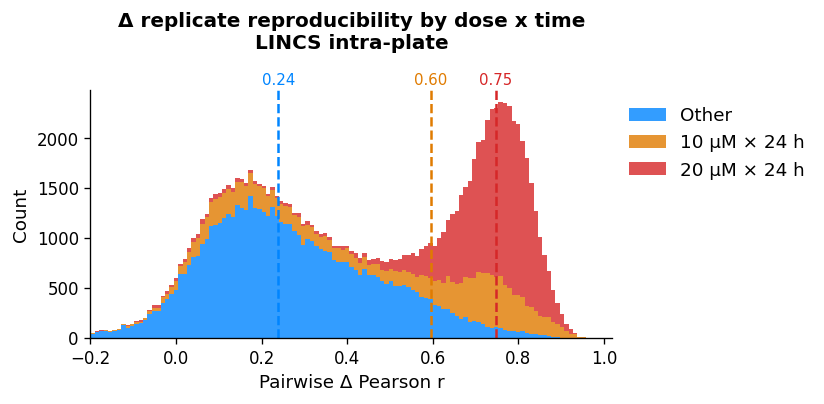

In [ ]:
# ── 2. Histogram: (10 uM, 24h) vs (20 uM, 24h) vs all other ──────────────────────
X_LIM2 = (-0.2, 1.02)
BINS2  = np.linspace(*X_LIM2, 120)

fig, ax = plt.subplots(figsize=(7, 3.5)) 

ax.hist([vals_rest, vals_10_24, vals_20_24], bins=BINS2, stacked=True,
        color=[BLUE, ORANGE, RED], alpha=0.8, linewidth=0,
        label=["Other", "10 µM × 24 h", "20 µM × 24 h"])

for vals, color in [(vals_rest, BLUE), (vals_10_24, ORANGE), (vals_20_24, RED)]:
    med = np.median(vals)
    ax.axvline(med, color=color, lw=1.5, ls="--")
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(med, 1.01, f"{med:.2f}",
            transform=trans, ha="center", va="bottom", fontsize=FS_SMALL, color=color)

ax.set_xlabel("Pairwise Δ Pearson r", fontsize=FS_LABEL)
ax.set_ylabel("Count", fontsize=FS_LABEL)
ax.set_title("Δ replicate reproducibility by dose x time\nLINCS intra-plate", fontsize=FS_TITLE, pad=25)
ax.set_xlim(*X_LIM2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=FS_LEGEND, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
fig.savefig(PLOT_DIR / "repro/lincs_bimodality.pdf", bbox_inches="tight")
plt.show()

### Gene-level variance vs. reproducibility

In [9]:
# ── Gene-level variance vs. reproducibility (ICC) ─────────────────────────────

REPRO_GENE_LEVELS = ["intra", "inter"]

GENE_VAR_PATH = {ds: RESULTS_DIR / ds / "gene_delta_variances.csv" for ds in DATASETS}
GENE_ICC_PATH = {
    ds: {level: RESULTS_DIR / ds / "repro" / f"gene_icc_{level}.csv" for level in REPRO_GENE_LEVELS}
    for ds in DATASETS
}

gene_var = {ds: pd.read_csv(GENE_VAR_PATH[ds]) for ds in DATASETS}
gene_icc = {
    ds: {level: pd.read_csv(GENE_ICC_PATH[ds][level]) for level in REPRO_GENE_LEVELS}
    for ds in DATASETS
}
gene_repro = {
    ds: {level: gene_var[ds].merge(gene_icc[ds][level], on="gene_idx") for level in REPRO_GENE_LEVELS}
    for ds in DATASETS
}

fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=False, sharey=True)

for row, ds in enumerate(DATASETS):
    for col, level in enumerate(REPRO_GENE_LEVELS):
        ax  = axes[row, col]
        sub = gene_repro[ds][level].dropna(subset=["variance", "icc"])

        ax.scatter(sub["variance"], sub["icc"], s=10, color=PALETTE[ds], alpha=0.4, linewidths=0)
        ax.set_xscale("log")

        r, _ = pearsonr(sub["variance"], sub["icc"])
        ax.text(0.03, 0.96, f"Pearson r = {r:.2f}\nn = {len(sub):,}",
                transform=ax.transAxes, ha="left", va="top", fontsize=FS_SMALL)

        ax.set_title(f"{DS_LABELS[ds]} — {level}-plate", fontsize=FS_TITLE)
        ax.spines[["top", "right"]].set_visible(False)

        if row == 1:
            ax.set_xlabel("Gene Δ variance (log scale)", fontsize=FS_LABEL)
        if col == 0:
            ax.set_ylabel("Gene reproducibility (ICC)", fontsize=FS_LABEL)

fig.suptitle("Gene variance vs. reproducibility", fontsize=FS_TITLE, y=1.0)
fig.tight_layout()
fig.savefig(PLOT_DIR / "repro/gene_variance_vs_icc.pdf", bbox_inches="tight")
plt.show()